# Build, evaluate, compare, and interpret machine learning models for continuous-value prediction.

In [97]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.linear_model import LinearRegression ,Lasso,Ridge,ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
#from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


In [98]:
# ! pip install imblearn

### Tasks 1. Select a regression dataset

In [99]:
import pandas as pd
path=r"D:\AI-Lab-99\5_Datacleaning,Preprocessing and Feature Engineering\house_prices\train.csv"
df=pd.read_csv(path)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Task 2. Establish a baseline model.

* **1. SET FEATURES AND COLUMNS**

In [100]:
X=df.drop('SalePrice',axis=1)
y=df['SalePrice']

X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)


* **2. ADVANCED PREPROCESSING PIPELINE**

In [101]:
num_col=df.select_dtypes(include=['int64','Float64']).columns.tolist()
num_col.remove('SalePrice')
cat_col=df.select_dtypes(include=['object']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoding', OneHotEncoder(handle_unknown='ignore', drop='first'))
])



C:\Users\MasterLaptops\AppData\Local\Temp\ipykernel_3132\4158867696.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=df.select_dtypes(include=['object']).columns.tolist()


#### Combine into a single transformer array

In [102]:

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])


#### Fit and transform the training split

In [103]:
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(X_train_proc.shape)
print(X_test_proc.shape)

c:\Users\MasterLaptops\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


(1168, 243)
(292, 243)


In [104]:
models={
    "Baseline (Mean)":DummyRegressor(strategy='mean'),
    "Linear Regression":LinearRegression(),
    "Rigid ":Ridge(alpha=10.0),
    "Lasso ": Lasso(alpha=100.0,max_iter=2000),
    "Elastic ": ElasticNet(alpha=10.0,l1_ratio=0.5),
    "Decision Tree":DecisionTreeRegressor(max_depth=6,random_state=42),
    "Random Forest Regressor": RandomForestRegressor(max_depth=6,n_estimators=6),
    "Gradient Boosting Regressor":GradientBoostingRegressor(n_estimators=10,learning_rate=0.1)
}

### Task 4. CROSS-VALIDATION & PERFORMANCE TESTING

In [105]:
result_list=[]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name,model in models.items():
    cv_score=cross_val_score(model,X_train_proc,y_train,cv=kf,scoring='r2')
    model.fit(X_train_proc,y_train)
    y_pred=model.predict(X_test_proc)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    result_list.append({
        'Model': name,
        'CV R2 (Mean)': np.mean(cv_score),
        'Test R2': r2,
        'Test MAE': mae,
        'Test RMSE': rmse
    })


### 5. Compare model performance

In [106]:
results_df = pd.DataFrame(result_list)
print("\n=================== MODEL PERFORMANCE COMPARISON ===================")
print(results_df.to_string(index=False))


=================== MODEL PERFORMANCE COMPARISON ===================
                      Model  CV R2 (Mean)   Test R2     Test MAE    Test RMSE
            Baseline (Mean)     -0.001623 -0.000882 62575.926452 87619.034506
          Linear Regression      0.749643  0.686375 20113.601715 49046.959036
                     Rigid       0.826068  0.876491 18765.684655 30779.152411
                     Lasso       0.822807  0.872847 18649.599555 31229.849019
                   Elastic       0.650091  0.643505 30694.780815 52291.775475
              Decision Tree      0.708907  0.788296 26087.531843 40296.883308
    Random Forest Regressor      0.780073  0.855796 21509.865620 33257.954565
Gradient Boosting Regressor      0.658844  0.683334 32365.381429 49284.168914


### 6. Analyze residuals. 

In [115]:
best_model_name=results_df[results_df['Model']!='Baseline (Mean)'].sort_values(by='Test R2',ascending=False)['Model'].values[0]
best_model=models[best_model_name]

best_pred=best_model.predict(X_test_proc)
residuals=y_test - best_pred


Text(0, 0.5, 'Residuals (Error)')

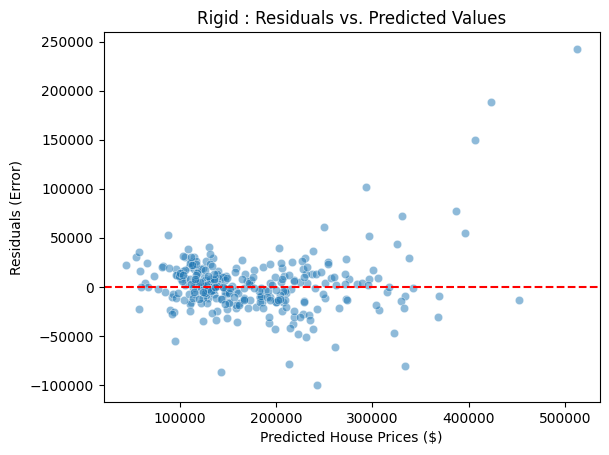

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=best_pred, y=residuals, color='#1f77b4', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title(f'{best_model_name}: Residuals vs. Predicted Values')
plt.xlabel('Predicted House Prices ($)')
plt.ylabel('Residuals (Error)')


[Visuals Processed]: Displaying error analysis and residual behavior plots for Rigid .


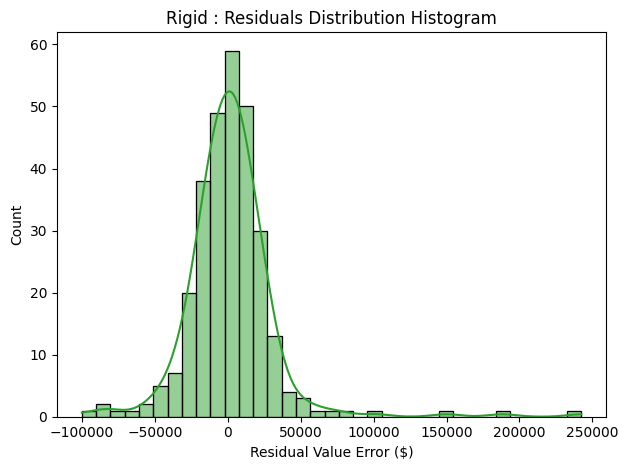

In [ ]:

sns.histplot(residuals, kde=True, color='#2ca02c')
plt.title(f'{best_model_name}: Residuals Distribution Histogram')
plt.xlabel('Residual Value Error ($)')

plt.tight_layout()
print(f"\n[Visuals Processed]: Displaying error analysis and residual behavior plots for {best_model_name}.")
plt.show()